In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil, subprocess, json, math, time, random, glob
from pathlib import Path

DRIVE = Path("/content/drive/MyDrive/CS232")
for sub in ("videos","ckpt","results"):
    (DRIVE/sub).mkdir(parents=True, exist_ok=True)

# thu muc lam viec cuc bo (nhanh) - mat khi het phien
WORK = Path("/content/work"); WORK.mkdir(exist_ok=True)
DATA=WORK/"vsr_data"; EV=WORK/"vsr_eval"; FG=WORK/"vsr_figs"
CK = DRIVE/"ckpt"                      # checkpoint ghi thang vao Drive
for d in (DATA,EV,FG): d.mkdir(parents=True, exist_ok=True)

def free_gb():
    st=os.statvfs("/content"); return st.f_bavail*st.f_frsize/1e9
print(f"Dia cuc bo con trong: {free_gb():.1f} GB")

import torch
assert torch.cuda.is_available(), "Runtime > Change runtime type > GPU"
gpu = torch.cuda.get_device_name(0)
vram = torch.cuda.get_device_properties(0).total_memory/1e9
print(f"GPU: {gpu}, {vram:.1f} GB VRAM")
if "A100" in gpu:
    print("  Luu y: A100 tieu compute unit rat nhanh. T4 hoac L4 la du cho bai nay.")

T_START=time.time(); BUDGET_H=11.0
def elapsed_h(): return (time.time()-T_START)/3600
def check_budget(label=""):
    e=elapsed_h(); print(f"[{e:.2f}h / {BUDGET_H}h] {label}"); return e<BUDGET_H

EXTS = ("*.mp4","*.mkv","*.webm","*.mov","*.avi","*.MP4","*.MOV")
vids = sorted(sum([glob.glob(str(DRIVE/"videos"/e)) for e in EXTS], []))
print(f"\n{len(vids)} video trong Drive/CS232/videos/")
for v in vids[:10]: print(f"  {Path(v).name}  {os.path.getsize(v)/1e6:.0f} MB")
assert vids, "Chua co video. Upload file 1080p vao MyDrive/CS232/videos/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dia cuc bo con trong: 191.3 GB
GPU: Tesla T4, 15.6 GB VRAM

5 video trong Drive/CS232/videos/
  11918864_1080_1920_50fps.mp4  10 MB
  11938123_1080_1920_50fps.mp4  11 MB
  12291834_1920_1080_30fps.mp4  422 MB
  13189433_3840_2160_60fps.mp4  185 MB
  15599342-hd_1080_1920_30fps.mp4  6 MB


In [ ]:
!pip install -q lpips 2>/dev/null
import numpy as np, cv2, torch.nn as nn, torch.nn.functional as F
import pandas as pd, matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

DEVICE="cuda"
CFG = dict(
    scale=4, hr=(1920,1080), fps=24,
    n_clips=8, clip_len=5, val_clips=2,
    seq_train=7, patch_lr=64, batch=2,
    crf_list=[23,28,33,38],
    eval_bitrates=[200,400,800,1500],
    lr_gen=5e-5, train_hours=6.5, seed=42,
)
S=CFG["scale"]; HRW,HRH=CFG["hr"]; LRW,LRH=HRW//S, HRH//S
random.seed(CFG["seed"]); np.random.seed(CFG["seed"]); torch.manual_seed(CFG["seed"])
torch.backends.cudnn.benchmark=True

def run(cmd, t=1800):
    r=subprocess.run(cmd, shell=True, capture_output=True, text=True, timeout=t)
    if r.returncode!=0: raise RuntimeError(f"{cmd}\n{r.stderr[-1200:]}")
    return r.stdout

print(run("ffmpeg -version | head -1").strip())
for lib in ["libx265","libx264"]:
    ok = subprocess.run(f"ffmpeg -hide_banner -encoders 2>/dev/null | grep -q {lib}",
                        shell=True).returncode==0
    print(f"{lib}: {'OK' if ok else 'THIEU'}")
print(f"\nLR {LRW}x{LRH} -> HR {HRW}x{HRH} (x{S})")
check_budget("setup xong")

ffmpeg version 6.1.1-3ubuntu5 Copyright (c) 2000-2023 the FFmpeg developers
libx265: OK
libx264: OK

LR 480x270 -> HR 1920x1080 (x4)
[0.00h / 11.0h] setup xong


True

In [ ]:
URLS = {
 "basicvsr": "https://download.openmmlab.com/mmediting/restorers/basicvsr/"
             "basicvsr_reds4_20120409-0e599677.pth",
 "spynet":   "https://download.openmmlab.com/mmediting/restorers/basicvsr/"
             "spynet_20210409-c6c1bd09.pth",
}
paths={}
for name,url in URLS.items():
    p = CK/f"{name}.pth"
    if not p.exists():
        print(f"tai {name} ...", end=" ", flush=True)
        try:
            run(f'wget -q --timeout=180 -O {p} "{url}"', 600)
            print(f"{os.path.getsize(p)/1e6:.1f} MB")
        except Exception as e:
            print("LOI:", str(e)[:200])
    paths[name]=p

sd_raw = torch.load(paths["basicvsr"], map_location="cpu")
sd = sd_raw.get("state_dict", sd_raw)
sd = { (k[len("generator."):] if k.startswith("generator.") else k): v for k,v in sd.items() }
print(f"\n{len(sd)} tham so trong checkpoint BasicVSR\n")

# in cay ten theo nhom
from collections import OrderedDict
groups=OrderedDict()
for k in sd:
    top=k.split(".")[0]
    groups.setdefault(top, []).append(k)
for g,ks in groups.items():
    print(f"{g:24s} {len(ks):4d} tham so | vd: {ks[0]}")
print("\nVai shape quan trong:")
for k in list(sd)[:3] + [k for k in sd if "fusion" in k or "conv_last" in k][:4]:
    print(f"  {k:52s} {tuple(sd[k].shape)}")
check_budget("tai weights xong")


316 tham so trong checkpoint BasicVSR

spynet                     62 tham so | vd: spynet.mean
backward_resblocks        122 tham so | vd: backward_resblocks.main.0.weight
forward_resblocks         122 tham so | vd: forward_resblocks.main.0.weight
fusion                      2 tham so | vd: fusion.weight
upsample1                   2 tham so | vd: upsample1.upsample_conv.weight
upsample2                   2 tham so | vd: upsample2.upsample_conv.weight
conv_hr                     2 tham so | vd: conv_hr.weight
conv_last                   2 tham so | vd: conv_last.weight

Vai shape quan trong:
  spynet.mean                                          (1, 3, 1, 1)
  spynet.std                                           (1, 3, 1, 1)
  spynet.basic_module.0.basic_module.0.conv.weight     (32, 8, 7, 7)
  fusion.weight                                        (64, 128, 1, 1)
  fusion.bias                                          (64,)
  conv_last.weight                                     (3, 64, 

True

In [ ]:
def flow_warp(x, flow, interp="bilinear", pad="border", align=True):
    # x: (n,c,h,w), flow: (n,h,w,2) don vi pixel
    n,c,h,w = x.size()
    gy,gx = torch.meshgrid(torch.arange(h, device=x.device, dtype=x.dtype),
                           torch.arange(w, device=x.device, dtype=x.dtype), indexing="ij")
    grid = torch.stack((gx,gy), 2).float()                    # (h,w,2)
    g = grid.unsqueeze(0) + flow
    gx_ = 2.0*g[...,0]/max(w-1,1) - 1.0
    gy_ = 2.0*g[...,1]/max(h-1,1) - 1.0
    return F.grid_sample(x, torch.stack((gx_,gy_), dim=3), mode=interp,
                         padding_mode=pad, align_corners=align)

class ConvModule(nn.Module):
    # tuong duong mmcv ConvModule: sinh key dang '<ten>.conv.weight'
    def __init__(self, i, o, act=True):
        super().__init__()
        self.conv = nn.Conv2d(i,o,7,1,3)
        self.activate = nn.ReLU(inplace=True) if act else None
    def forward(self,x):
        x=self.conv(x)
        return self.activate(x) if self.activate is not None else x

class SPyNetBasicModule(nn.Module):
    # ten 'basic_module' va thu tu 0..4 phai khop checkpoint
    def __init__(self):
        super().__init__()
        self.basic_module = nn.Sequential(
            ConvModule(8,32), ConvModule(32,64), ConvModule(64,32),
            ConvModule(32,16), ConvModule(16,2, act=False))
    def forward(self, x): return self.basic_module(x)

class SPyNet(nn.Module):
    def __init__(self, n_level=6):
        super().__init__()
        self.basic_module = nn.ModuleList([SPyNetBasicModule() for _ in range(n_level)])
        self.register_buffer("mean", torch.tensor([.485,.456,.406]).view(1,3,1,1))
        self.register_buffer("std",  torch.tensor([.229,.224,.225]).view(1,3,1,1))
    def compute_flow(self, ref, supp):
        n,_,h,w = ref.size()
        ref=[(ref-self.mean)/self.std]; supp=[(supp-self.mean)/self.std]
        for _ in range(5):
            ref.append(F.avg_pool2d(ref[-1],2,2,count_include_pad=False))
            supp.append(F.avg_pool2d(supp[-1],2,2,count_include_pad=False))
        ref=ref[::-1]; supp=supp[::-1]
        flow = ref[0].new_zeros(n,2,h//32,w//32)
        for lv in range(len(ref)):
            if lv==0: up=flow
            else:
                up = F.interpolate(flow, scale_factor=2, mode="bilinear", align_corners=True)*2.0
            flow = up + self.basic_module[lv](torch.cat([
                ref[lv], flow_warp(supp[lv], up.permute(0,2,3,1), pad="border"), up], 1))
        return flow
    def forward(self, ref, supp):
        n,_,h,w = ref.size()
        hu = int(math.ceil(h/32))*32; wu = int(math.ceil(w/32))*32
        ref = F.interpolate(ref, size=(hu,wu), mode="bilinear", align_corners=False)
        supp= F.interpolate(supp,size=(hu,wu), mode="bilinear", align_corners=False)
        flow = F.interpolate(self.compute_flow(ref,supp), size=(h,w),
                             mode="bilinear", align_corners=False)
        flow[:,0,:,:] *= float(w)/float(wu); flow[:,1,:,:] *= float(h)/float(hu)
        return flow

class ResidualBlockNoBN(nn.Module):
    def __init__(self, mid=64, res_scale=1.0):
        super().__init__()
        self.conv1=nn.Conv2d(mid,mid,3,1,1); self.conv2=nn.Conv2d(mid,mid,3,1,1)
        self.relu=nn.ReLU(inplace=True); self.res_scale=res_scale
    def forward(self,x): return x + self.conv2(self.relu(self.conv1(x)))*self.res_scale

class ResidualBlocksWithInputConv(nn.Module):
    def __init__(self, in_ch, out_ch=64, num_blocks=30):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(in_ch,out_ch,3,1,1), nn.LeakyReLU(0.1, inplace=True),
            nn.Sequential(*[ResidualBlockNoBN(out_ch) for _ in range(num_blocks)]))
    def forward(self,x): return self.main(x)

class PixelShufflePack(nn.Module):
    def __init__(self, in_ch, out_ch, scale, kernel=3):
        super().__init__()
        self.scale=scale
        self.upsample_conv = nn.Conv2d(in_ch, out_ch*scale*scale, kernel, padding=(kernel-1)//2)
    def forward(self,x): return F.pixel_shuffle(self.upsample_conv(x), self.scale)

class BasicVSRNet(nn.Module):
    def __init__(self, mid=64, num_blocks=30):
        super().__init__()
        self.spynet = SPyNet()
        self.backward_resblocks = ResidualBlocksWithInputConv(mid+3, mid, num_blocks)
        self.forward_resblocks  = ResidualBlocksWithInputConv(mid+3, mid, num_blocks)
        self.fusion   = nn.Conv2d(mid*2, mid, 1, 1, 0)
        self.upsample1= PixelShufflePack(mid, mid, 2, 3)
        self.upsample2= PixelShufflePack(mid, 64, 2, 3)
        self.conv_hr  = nn.Conv2d(64,64,3,1,1)
        self.conv_last= nn.Conv2d(64,3,3,1,1)
        self.img_upsample = nn.Upsample(scale_factor=4, mode="bilinear", align_corners=False)
        self.lrelu = nn.LeakyReLU(0.1, inplace=True)

    def compute_flow(self, lrs):
        n,t,c,h,w = lrs.size()
        a = lrs[:,:-1].reshape(-1,c,h,w)
        b = lrs[:,1:].reshape(-1,c,h,w)
        flows_backward = self.spynet(a,b).view(n,t-1,2,h,w)
        flows_forward  = self.spynet(b,a).view(n,t-1,2,h,w)
        return flows_forward, flows_backward

    def forward(self, lrs):
        n,t,c,h,w = lrs.size()
        flows_forward, flows_backward = self.compute_flow(lrs)
        outputs=[]
        feat = lrs.new_zeros(n,64,h,w)
        for i in range(t-1, -1, -1):                    # luot NGUOC
            if i < t-1:
                feat = flow_warp(feat, flows_backward[:,i].permute(0,2,3,1))
            feat = self.backward_resblocks(torch.cat([lrs[:,i], feat],1))
            outputs.append(feat)
        outputs = outputs[::-1]
        feat = torch.zeros_like(feat)
        for i in range(0, t):                           # luot XUOI
            if i > 0:
                feat = flow_warp(feat, flows_forward[:,i-1].permute(0,2,3,1))
            feat = self.forward_resblocks(torch.cat([lrs[:,i], feat],1))
            out = self.lrelu(self.fusion(torch.cat([outputs[i], feat],1)))
            out = self.lrelu(self.upsample1(out))
            out = self.lrelu(self.upsample2(out))
            out = self.lrelu(self.conv_hr(out))
            out = self.conv_last(out)
            outputs[i] = out + self.img_upsample(lrs[:,i])
        return torch.stack(outputs, dim=1)

# ---------- MOC A: nap weights ----------
net = BasicVSRNet()
own = net.state_dict()
missing   = [k for k in own if k not in sd]
unexpected= [k for k in sd  if k not in own]
shape_bad = [k for k in own if k in sd and tuple(own[k].shape)!=tuple(sd[k].shape)]
print(f"khop  : {len(own)-len(missing)}/{len(own)}")
print(f"thieu : {len(missing)}   thua: {len(unexpected)}   lech shape: {len(shape_bad)}")
if missing:    print("  vd thieu :", missing[:4])
if unexpected: print("  vd thua  :", unexpected[:4])
if shape_bad:  print("  vd lech  :", [(k, tuple(own[k].shape), tuple(sd[k].shape)) for k in shape_bad[:3]])

OK_A = (len(missing)==0 and len(shape_bad)==0)
if OK_A:
    net.load_state_dict(sd, strict=False)
    print("\n>>> MOC A DAT: nap weights thanh cong")
else:
    print("\n>>> MOC A HONG: gui ket qua cell nay de sua kien truc")
net = net.to(DEVICE).eval()
print(f"Tham so: {sum(p.numel() for p in net.parameters())/1e6:.2f}M")
check_budget("moc A")

khop  : 316/316
thieu : 0   thua: 0   lech shape: 0

>>> MOC A DAT: nap weights thanh cong
Tham so: 6.29M
[0.00h / 11.0h] moc A


True

In [ ]:
def gpu_mem_gb(): return torch.cuda.max_memory_allocated()/1e9

rows=[]
print(f"Do o {LRW}x{LRH} (LR) -> {HRW}x{HRH} (HR)\n")
for T in [2,3,5,7,10,15,20,30]:
    torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
    try:
        x = torch.rand(1,T,3,LRH,LRW, device=DEVICE)
        torch.cuda.synchronize(); t0=time.perf_counter()
        with torch.no_grad(), torch.autocast("cuda", torch.float16):
            y = net(x)
        torch.cuda.synchronize(); dt=time.perf_counter()-t0
        rows.append(dict(seq=T, mem_GB=round(gpu_mem_gb(),2), giay=round(dt,2),
                         fps=round(T/dt,2), trang_thai="OK"))
        del x,y
    except torch.cuda.OutOfMemoryError:
        rows.append(dict(seq=T, mem_GB=np.nan, giay=np.nan, fps=np.nan, trang_thai="OOM"))
        torch.cuda.empty_cache(); break
    except Exception as e:
        rows.append(dict(seq=T, mem_GB=np.nan, giay=np.nan, fps=np.nan,
                         trang_thai=str(e)[:40])); break
MEM = pd.DataFrame(rows); display(MEM)

ok = MEM[MEM.trang_thai=="OK"]
MAX_INFER = int(ok.seq.max()) if len(ok) else 0
print(f"\nChuoi toi da khi SUY LUAN: {MAX_INFER} frame")
if len(ok):
    print(f"Toc do: {ok.fps.iloc[-1]:.2f} fps (muc tieu real-time la 24)")

# uoc luong cho huan luyen: patch nho hon nhieu nen thu truc tiep
print(f"\nThu HUAN LUYEN voi patch {CFG['patch_lr']}x{CFG['patch_lr']}, chuoi {CFG['seq_train']}:")
try:
    torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
    net.train()
    xb = torch.rand(CFG["batch"], CFG["seq_train"], 3, CFG["patch_lr"], CFG["patch_lr"], device=DEVICE)
    yb = torch.rand(CFG["batch"], CFG["seq_train"], 3, CFG["patch_lr"]*S, CFG["patch_lr"]*S, device=DEVICE)
    with torch.autocast("cuda", torch.float16):
        loss = F.l1_loss(net(xb), yb)
    loss.backward()
    print(f"  OK, bo nho dinh: {gpu_mem_gb():.2f} GB")
    OK_B = True
except torch.cuda.OutOfMemoryError:
    print("  OOM -> giam patch_lr hoac seq_train")
    OK_B = False
net.zero_grad(set_to_none=True); net.eval(); torch.cuda.empty_cache()

print(f"\n>>> MOC B {'DAT' if OK_B and MAX_INFER>=3 else 'HONG'}")
check_budget("moc B")

Do o 480x270 (LR) -> 1920x1080 (HR)



,seq,mem_GB,giay,fps,trang_thai
0,2,2.01,0.47,4.23,OK
1,3,2.04,0.65,4.65,OK
2,5,2.10,1.09,4.58,OK
3,7,2.15,1.54,4.54,OK
4,10,2.24,2.22,4.51,OK
5,15,2.38,3.30,4.55,OK
6,20,2.52,4.41,4.54,OK
7,30,2.89,6.65,4.51,OK



Chuoi toi da khi SUY LUAN: 30 frame
Toc do: 4.51 fps (muc tieu real-time la 24)

Thu HUAN LUYEN voi patch 64x64, chuoi 7:
  OK, bo nho dinh: 2.20 GB

>>> MOC B DAT
[0.01h / 11.0h] moc B


True

In [ ]:

HRD=DATA/"hr"; HRD.mkdir(exist_ok=True)
clips=[]; cid=0
nper = max(1, math.ceil(CFG["n_clips"]/len(vids)))
for v in vids:
    if cid>=CFG["n_clips"]: break
    try: dur=float(run(f'ffprobe -v error -show_entries format=duration -of csv=p=0 "{v}"').strip())
    except Exception: continue
    usable=dur-CFG["clip_len"]-2
    if usable<=2: continue
    for ss in np.linspace(1, usable, nper):
        if cid>=CFG["n_clips"]: break
        out=HRD/f"c{cid:02d}.mp4"
        if not out.exists():
            run(f'ffmpeg -y -loglevel error -ss {ss:.2f} -i "{v}" -t {CFG["clip_len"]} '
                f'-vf "scale={HRW}:{HRH}:flags=lanczos,fps={CFG["fps"]}" '
                f'-c:v libx264 -preset slow -crf 8 -pix_fmt yuv420p -an {out}', 600)
        clips.append(dict(id=cid, path=out)); cid+=1

random.Random(CFG["seed"]).shuffle(clips)
VAL=clips[:CFG["val_clips"]]; TRAIN=clips[CFG["val_clips"]:]
print(f"{len(clips)} clip | train {len(TRAIN)} | val {len(VAL)}")

def extract(video, outdir, vf=None):
    outdir=Path(outdir)
    if outdir.exists() and len(list(outdir.glob("*.png")))>0: return outdir
    outdir.mkdir(parents=True, exist_ok=True)
    vfa=f'-vf "{vf}"' if vf else ""
    run(f'ffmpeg -y -loglevel error -i {video} {vfa} {outdir}/%04d.png', 900)
    return outdir

STORE={}
for c in tqdm(clips, desc="sinh du lieu"):
    gt=extract(c["path"], DATA/f"gt{c['id']:02d}")
    for crf in CFG["crf_list"]:
        lrv=DATA/f"lr_c{c['id']:02d}_crf{crf}.mp4"
        if not lrv.exists():
            run(f'ffmpeg -y -loglevel error -i {c["path"]} '
                f'-vf "scale={LRW}:{LRH}:flags=lanczos" -c:v libx265 -preset medium '
                f'-crf {crf} -x265-params log-level=error -pix_fmt yuv420p -an {lrv}', 900)
        lrd=extract(lrv, DATA/f"lr_c{c['id']:02d}_crf{crf}")
        n=min(len(list(lrd.glob('*.png'))), len(list(Path(gt).glob('*.png'))))
        STORE[(c["id"],crf)]=dict(lr=lrd, gt=gt, n=n)

print(f"\n{len(STORE)} to hop (clip, CRF) | dia con: {free_gb():.1f} GB")
check_budget("sinh du lieu xong")

8 clip | train 6 | val 2


sinh du lieu:   0%|          | 0/8 [00:00<?, ?it/s]


32 to hop (clip, CRF) | dia con: 191.3 GB
[0.01h / 11.0h] sinh du lieu xong


True

In [ ]:
import lpips
lp = lpips.LPIPS(net="alex", verbose=False).to(DEVICE).eval()
from skimage.metrics import structural_similarity

def to_y(b): return cv2.cvtColor(b, cv2.COLOR_BGR2YCrCb)[:,:,0].astype(np.float64)
def psnr_y(a,b):
    m=np.mean((to_y(a)-to_y(b))**2); return 99.0 if m==0 else 10*np.log10(255.0**2/m)
def ssim_y(a,b): return structural_similarity(to_y(a),to_y(b),data_range=255.0)
@torch.no_grad()
def lpd(a,b):
    t=lambda im: torch.from_numpy(np.ascontiguousarray(im[:,:,::-1]).astype(np.float32)/127.5-1
                                  ).permute(2,0,1)[None].to(DEVICE)
    return lp(t(a),t(b)).item()
def kbps_of(p):
    d=float(run(f'ffprobe -v error -show_entries format=duration -of csv=p=0 {p}').strip())
    return os.path.getsize(p)*8/d/1000

CHUNK = max(2, min(MAX_INFER, 10))
@torch.no_grad()
def vsr_infer(model, lr_dir, out_dir, chunk=CHUNK, overlap=1):
    out_dir=Path(out_dir); shutil.rmtree(out_dir, ignore_errors=True); out_dir.mkdir(parents=True)
    files=sorted(Path(lr_dir).glob("*.png")); N=len(files)
    model.eval(); t0=time.perf_counter(); i=0
    while i < N:
        j=min(i+chunk, N)
        s=max(0, i-overlap); e=min(N, j+overlap)          # dem de tranh dut doan
        imgs=[cv2.imread(str(f))[:,:,::-1].astype(np.float32)/255. for f in files[s:e]]
        x=torch.from_numpy(np.ascontiguousarray(np.stack(imgs))).permute(0,3,1,2)[None].to(DEVICE)
        with torch.autocast("cuda", torch.float16):
            y=model(x).float().clamp(0,1)[0]
        for k in range(i,j):
            a=y[k-s].permute(1,2,0).cpu().numpy()[:,:,::-1]
            cv2.imwrite(str(out_dir/files[k].name), (a*255).round().astype(np.uint8))
        del x,y; torch.cuda.empty_cache(); i=j
    return N/(time.perf_counter()-t0)

def eval_dir(fdir, gt_files, gt_temporal):
    ps,ss,lps,tl=[],[],[],[]; po=None
    for i,f in enumerate(sorted(Path(fdir).glob("*.png"))):
        if i>=len(gt_files): break
        o=cv2.imread(str(f)); g=cv2.imread(str(gt_files[i]))
        ps.append(psnr_y(o,g)); ss.append(ssim_y(o,g)); lps.append(lpd(o,g))
        if po is not None: tl.append(abs(lpd(o,po)-gt_temporal[i-1]))
        po=o
    return dict(psnr_y=np.mean(ps), ssim=np.mean(ss), lpips=np.mean(lps),
                tlp=np.mean(tl) if tl else np.nan)

def gt_temporal_of(gt_files):
    out=[]; pg=None
    for f in gt_files:
        g=cv2.imread(str(f))
        if pg is not None: out.append(lpd(g,pg))
        pg=g
    return out

def full_eval(model, tag, rows):
    for c in VAL:
        gt_files=sorted((DATA/f"gt{c['id']:02d}").glob("*.png"))
        gtt=gt_temporal_of(gt_files)
        for br in CFG["eval_bitrates"]:
            va=EV/f"A_c{c['id']}_{br}.mp4"
            if not va.exists():
                run(f'ffmpeg -y -loglevel error -i {c["path"]} -c:v libx265 -preset medium '
                    f'-b:v {br}k -maxrate {int(br*1.5)}k -bufsize {br*3}k '
                    f'-x265-params log-level=error -pix_fmt yuv420p -an {va}', 900)
            da=extract(va, EV/f"A_c{c['id']}_{br}")
            if not any(r["method"]=="A: H.265 1080p" and r["clip"]==c["id"] and r["target"]==br
                       for r in rows):
                rows.append(dict(clip=c["id"], method="A: H.265 1080p", target=br,
                                 kbps=kbps_of(va), fps=np.nan, **eval_dir(da, gt_files, gtt)))
            vl=EV/f"LR_c{c['id']}_{br}.mp4"
            if not vl.exists():
                run(f'ffmpeg -y -loglevel error -i {c["path"]} '
                    f'-vf "scale={LRW}:{LRH}:flags=lanczos" -c:v libx265 -preset medium '
                    f'-b:v {br}k -maxrate {int(br*1.5)}k -bufsize {br*3}k '
                    f'-x265-params log-level=error -pix_fmt yuv420p -an {vl}', 900)
            lrk=kbps_of(vl); dlr=extract(vl, EV/f"LR_c{c['id']}_{br}")
            od=EV/f"{tag}_c{c['id']}_{br}"
            f_=vsr_infer(model, dlr, od)
            rows.append(dict(clip=c["id"], method=tag, target=br, kbps=lrk, fps=f_,
                             **eval_dir(od, gt_files, gtt)))
    return rows

ROWS=[]
ROWS=full_eval(net, "V: BasicVSR pretrained", ROWS)
BASE=pd.DataFrame(ROWS); display(BASE.round(4))
BASE.to_csv(WORK/"vsr_baseline.csv", index=False)
check_budget("baseline xong")

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


,clip,method,target,kbps,fps,psnr_y,ssim,lpips,tlp
0,3,A: H.265 1080p,200,184.1792,NaN,37.3504,0.9581,0.1649,0.0137
1,3,V: BasicVSR pretrained,200,194.5568,2.5741,39.4699,0.9666,0.1240,0.0042
2,3,A: H.265 1080p,400,351.7776,NaN,41.1213,0.9732,0.0971,0.0053
3,3,V: BasicVSR pretrained,400,383.8336,2.5812,41.5097,0.9738,0.0942,0.0027
4,3,A: H.265 1080p,800,707.7312,NaN,44.3901,0.9820,0.0545,0.0022
5,3,V: BasicVSR pretrained,800,767.5168,2.5693,42.9891,0.9786,0.0773,0.0017
6,3,A: H.265 1080p,1500,1364.1056,NaN,46.5324,0.9865,0.0339,0.0022
7,3,V: BasicVSR pretrained,1500,1466.2048,2.5542,43.8402,0.9814,0.0691,0.0012
8,4,A: H.265 1080p,200,155.6560,NaN,25.9794,0.7518,0.3828,0.0091
9,4,V: BasicVSR pretrained,200,176.2256,2.2530,24.8494,0.7236,0.3423,0.0094


[0.49h / 11.0h] baseline xong


True

2708 chuoi huan luyen


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Da doi ten checkpoint cu -> basicvsr_h265_L1only.pt
Da nap lai weights BasicVSR goc


fine-tune L1+LPIPS: 0it [00:00, ?it/s]


[it 2000] mo dong bang SPyNet

Het ngan sach huan luyen (6.5h), dung o iteration 30494
Da chay 30494 iteration


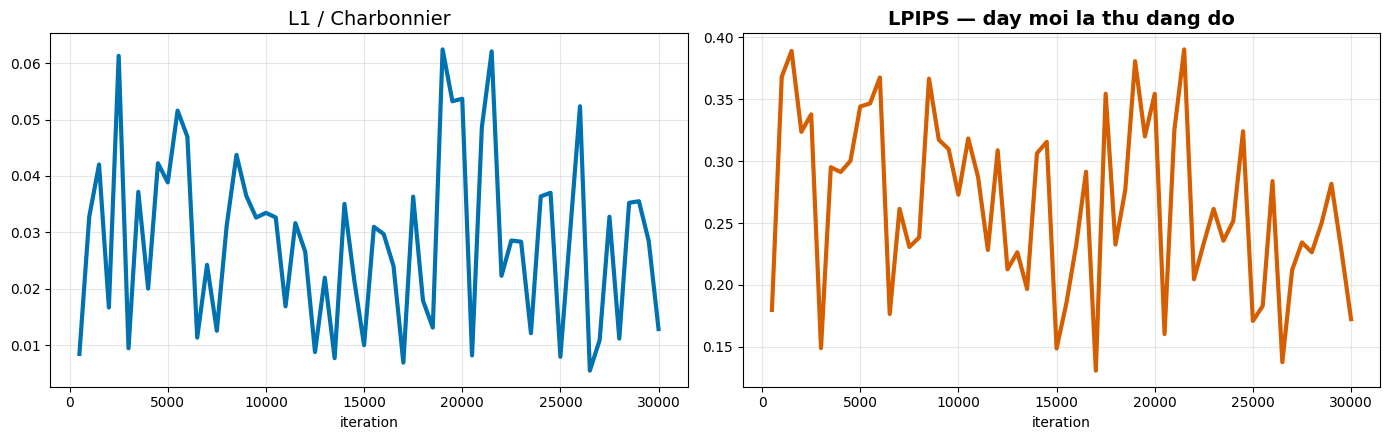

,it,loss,pix,lpips,h
52,26500,0.01920,0.00545,0.13757,5.66667
53,27000,0.03207,0.01086,0.21216,5.77098
54,27500,0.05620,0.03276,0.23438,5.87643
55,28000,0.03378,0.01113,0.22644,5.98178
56,28500,0.06022,0.03523,0.25000,6.08615
57,29000,0.06368,0.03551,0.28174,6.19050
58,29500,0.05133,0.02845,0.22888,6.29482
59,30000,0.03007,0.01283,0.17236,6.40166



LPIPS tu it 1500 den 30000: -0.2168
[6.51h / 11.0h] moc C - huan luyen xong


True

In [ ]:
# =========================================================================
# PHAN 7 (ban sua) — Fine-tune BasicVSR voi loss L1 + LPIPS
#
# Thay doi so voi ban cu:
#   1. Them LPIPS vao loss  -> toi uu dung thu dang do
#   2. Xoa checkpoint cu    -> khong resume tu model da hoc sai huong
#   3. Nap lai weights goc  -> net trong bo nho dang la ban fine-tune cu
#   4. Theo doi rieng l_pix va l_lpips
# =========================================================================

class SeqDS(Dataset):
    def __init__(self, store, ids, seq=7, patch=64):
        self.items=[]
        for (cid,crf),v in store.items():
            if cid not in ids: continue
            for t0 in range(0, v["n"]-seq):
                self.items.append((cid,crf,t0))
        self.store=store; self.seq=seq; self.p=patch
    def __len__(self): return len(self.items)
    def __getitem__(self,i):
        cid,crf,t0=self.items[i]; v=self.store[(cid,crf)]
        p=self.p
        probe=cv2.imread(str(v["lr"]/f"{t0+1:04d}.png"))
        if probe is None: return self[(i+1)%len(self)]
        h,w=probe.shape[:2]
        if h<p or w<p: return self[(i+1)%len(self)]
        y=random.randint(0,h-p); x=random.randint(0,w-p)
        fh = random.random()<0.5; fv = random.random()<0.5
        to_t=lambda a: torch.from_numpy(
            np.ascontiguousarray(a[:,:,::-1]).astype(np.float32)/255.).permute(2,0,1)
        lrs,gts=[],[]
        for k in range(self.seq):
            lr=cv2.imread(str(v["lr"]/f"{t0+k+1:04d}.png"))
            gt=cv2.imread(str(Path(v["gt"])/f"{t0+k+1:04d}.png"))
            if lr is None or gt is None: return self[(i+1)%len(self)]
            a=lr[y:y+p, x:x+p]; b=gt[y*S:(y+p)*S, x*S:(x+p)*S]
            if fh: a,b=a[:,::-1],b[:,::-1]
            if fv: a,b=a[::-1],b[::-1]
            lrs.append(to_t(a)); gts.append(to_t(b))
        return torch.stack(lrs), torch.stack(gts)

tr=SeqDS(STORE, {c["id"] for c in TRAIN}, CFG["seq_train"], CFG["patch_lr"])
dl=DataLoader(tr, batch_size=CFG["batch"], shuffle=True, num_workers=2,
              pin_memory=True, drop_last=True, persistent_workers=True)
print(f"{len(tr)} chuoi huan luyen")

# ---------------- LOSS: L1 + LPIPS ----------------
import lpips
lp_vgg = lpips.LPIPS(net="vgg", verbose=False).to(DEVICE).eval()
for _p in lp_vgg.parameters(): _p.requires_grad_(False)

LAM_LPIPS = 0.1     # tang len 0.3 neu thanh phan lpips khong giam
N_LPIPS   = 3       # so frame giua chuoi dung de tinh LPIPS (giam neu OOM)

def gen_loss(out, gt, lam=LAM_LPIPS, n_lpips=N_LPIPS):
    T = out.shape[1]
    l_pix = torch.sqrt((out-gt)**2 + 1e-12).mean()          # Charbonnier
    k0 = max(0, T//2 - n_lpips//2); k1 = min(T, k0 + n_lpips)
    o = out[:, k0:k1].reshape(-1, *out.shape[2:]).clamp(0,1)
    g = gt[:,  k0:k1].reshape(-1, *gt.shape[2:])
    l_per = lp_vgg(o*2-1, g*2-1).mean()
    return l_pix + lam*l_per, l_pix.item(), l_per.item()

# ---------------- RESET: bo model da train bang loss cu ----------------
CKF = CK/"basicvsr_h265.pt"
CKF_OLD = CK/"basicvsr_h265_L1only.pt"
if CKF.exists():
    shutil.move(str(CKF), str(CKF_OLD))     # giu lai de so sanh trong bao cao
    print(f"Da doi ten checkpoint cu -> {CKF_OLD.name}")

net.load_state_dict(sd, strict=False)       # ve lai BasicVSR pretrained
net = net.to(DEVICE)
print("Da nap lai weights BasicVSR goc")

# ---------------- Huan luyen ----------------
net.train()
for p_ in net.spynet.parameters(): p_.requires_grad_(False)
opt=torch.optim.Adam([p_ for p_ in net.parameters() if p_.requires_grad], lr=CFG["lr_gen"])
scaler=torch.amp.GradScaler("cuda")
FIX_ITER=2000
it0=0; hist=[]
if CKF.exists():                             # chi resume trong CUNG mot lan chay
    s=torch.load(CKF, map_location=DEVICE)
    net.load_state_dict(s["net"]); opt.load_state_dict(s["opt"])
    it0=s["it"]; hist=s["hist"]
    print(f"resume tu iteration {it0}")

t_train0=time.time(); it=it0; di=iter(dl)
pbar=tqdm(desc="fine-tune L1+LPIPS")
while True:
    if (time.time()-t_train0)/3600 > CFG["train_hours"]:
        print(f"\nHet ngan sach huan luyen ({CFG['train_hours']}h), dung o iteration {it}"); break
    if elapsed_h() > BUDGET_H - 1.2:
        print(f"\nGan het ngan sach tong, dung o iteration {it}"); break
    if it == FIX_ITER:
        for p_ in net.spynet.parameters(): p_.requires_grad_(True)
        opt.add_param_group({"params": list(net.spynet.parameters()),
                             "lr": CFG["lr_gen"]*0.25})
        print(f"\n[it {it}] mo dong bang SPyNet")
    try: lrs,gts=next(di)
    except StopIteration: di=iter(dl); lrs,gts=next(di)
    lrs,gts=lrs.to(DEVICE,non_blocking=True), gts.to(DEVICE,non_blocking=True)

    with torch.autocast("cuda", torch.float16):
        loss, l_pix, l_per = gen_loss(net(lrs), gts)
    opt.zero_grad(set_to_none=True)
    scaler.scale(loss).backward()
    scaler.unscale_(opt); torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)
    scaler.step(opt); scaler.update()

    it+=1; pbar.update(1)
    if it%50==0:
        pbar.set_postfix(pix=f"{l_pix:.4f}", lpips=f"{l_per:.4f}", h=f"{elapsed_h():.1f}")
    if it%500==0:
        hist.append(dict(it=it, loss=loss.item(), pix=l_pix, lpips=l_per, h=elapsed_h()))
        torch.save(dict(net=net.state_dict(), opt=opt.state_dict(), it=it, hist=hist), CKF)
pbar.close(); net.eval()
torch.save(dict(net=net.state_dict(), opt=opt.state_dict(), it=it, hist=hist), CKF)
print(f"Da chay {it-it0} iteration")

if hist:
    h=pd.DataFrame(hist)
    fig,ax=plt.subplots(1,2, figsize=(14,4.5))
    ax[0].plot(h["it"], h["pix"], lw=3, color="#0072B2")
    ax[0].set_title("L1 / Charbonnier", fontsize=14)
    ax[1].plot(h["it"], h["lpips"], lw=3, color="#D55E00")
    ax[1].set_title("LPIPS — day moi la thu dang do", fontsize=14, fontweight="bold")
    for a_ in ax: a_.set_xlabel("iteration"); a_.grid(alpha=.3)
    plt.tight_layout(); plt.savefig(FG/"finetune_loss_v2.png", dpi=160); plt.show()
    display(h.tail(8).round(5))
    if len(h) > 3:
        d = h["lpips"].iloc[-1] - h["lpips"].iloc[2]
        print(f"\nLPIPS tu it {int(h['it'].iloc[2])} den {int(h['it'].iloc[-1])}: {d:+.4f}")
        if d > -0.002:
            print(">>> LPIPS gan nhu khong giam. Tang LAM_LPIPS len 0.3 va chay lai.")
check_budget("moc C - huan luyen xong")

=== Trung binh cac clip val ===


psnr_y    ssim   lpips     tlp     fps
method                 target                                         
A: H.265 1080p         200     31.6649  0.8549  0.2738  0.0114     NaN
                       400     34.8620  0.9073  0.1821  0.0071     NaN
                       800     37.7275  0.9416  0.1157  0.0059     NaN
                       1500    39.7244  0.9596  0.0750  0.0057     NaN
V+FT: fine-tune H.265  200     32.5158  0.8472  0.1979  0.0197  2.2831
                       400     33.6701  0.8691  0.1740  0.0164  2.2695
                       800     34.2869  0.8818  0.1560  0.0152  2.2294
                       1500    34.5427  0.8884  0.1453  0.0143  2.2388
V: BasicVSR pretrained 200     32.1596  0.8451  0.2332  0.0068  2.4136
                       400     33.5466  0.8705  0.1887  0.0057  2.4265
                       800     34.5594  0.8890  0.1581  0.0053  2.4160
                       1500    35.1488  0.9010  0.1413  0.0051  2.4135

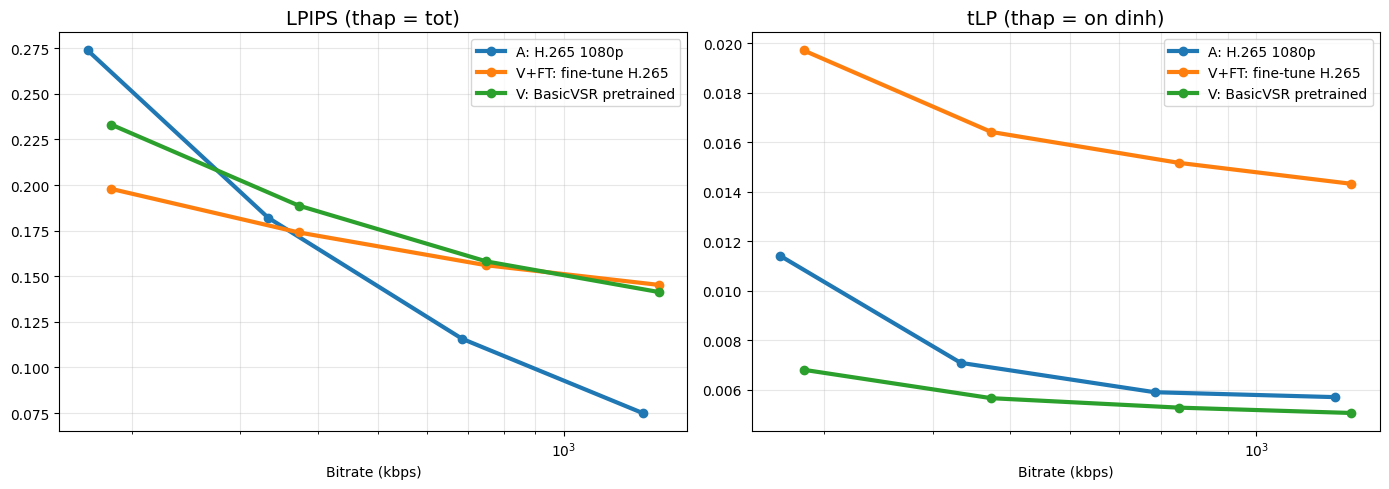


KET LUAN KHA THI
MOC A - nap weights        : DAT
MOC B - chay tren T4       : DAT  (chuoi toi da 30 frame khi suy luan)
MOC C - fine-tune cai thien: LPIPS -6.7%, PSNR -0.10 dB

Toc do: 2.42 fps (real-time can 24)
So iteration da chay: 30494
Tong thoi gian: 6.8h

>>> DANG DI TIEP. Fine-tune cai thien ro. Voi du lieu lon hon va
    nhieu iteration hon, cai thien nhieu kha nang con tang.

File de tai ve:
  compare_c3_1500kbps.mp4                3.51 MB
  compare_c3_200kbps.mp4                 3.45 MB
  compare_c4_1500kbps.mp4                9.78 MB
  compare_c4_200kbps.mp4                 8.32 MB
  finetune_loss_v2.png                   0.18 MB
  memory_profile.csv                     0.00 MB
  still_c3_200.png                       0.56 MB
  still_c4_200.png                       1.63 MB
  vsr_baseline.csv                       0.00 MB
  vsr_compare.png                        0.14 MB
  vsr_results.csv                        0.00 MB


In [ ]:
ROWS2=[r for r in ROWS]
ROWS2=full_eval(net, "V+FT: fine-tune H.265", ROWS2)
RES=pd.DataFrame(ROWS2); RES.to_csv(WORK/"vsr_results.csv", index=False)

M=RES.groupby(["method","target"])[["psnr_y","ssim","lpips","tlp","fps"]].mean().round(4)
print("=== Trung binh cac clip val ===")
display(M)

pre=RES[RES.method=="V: BasicVSR pretrained"]
ft =RES[RES.method=="V+FT: fine-tune H.265"]
a  =RES[RES.method=="A: H.265 1080p"]
d_lpips=100*(ft.lpips.mean()/pre.lpips.mean()-1)
d_psnr =ft.psnr_y.mean()-pre.psnr_y.mean()

fig,ax=plt.subplots(1,2,figsize=(14,5))
for m,g in RES.groupby("method"):
    g=g.groupby("target")[["lpips","tlp","kbps"]].mean().reset_index().sort_values("kbps")
    ax[0].plot(g.kbps,g.lpips,marker="o",lw=3,label=m)
    ax[1].plot(g.kbps,g.tlp,marker="o",lw=3,label=m)
for a_,t in zip(ax,["LPIPS (thap = tot)","tLP (thap = on dinh)"]):
    a_.set_xscale("log"); a_.set_xlabel("Bitrate (kbps)"); a_.set_title(t, fontsize=14)
    a_.grid(which="both",alpha=.3); a_.legend(fontsize=10)
plt.tight_layout(); plt.savefig(FG/"vsr_compare.png", dpi=160); plt.show()

print("\n"+"="*64)
print("KET LUAN KHA THI")
print("="*64)
print(f"MOC A - nap weights        : {'DAT' if OK_A else 'HONG'}")
print(f"MOC B - chay tren T4       : {'DAT' if OK_B else 'HONG'}  "
      f"(chuoi toi da {MAX_INFER} frame khi suy luan)")
print(f"MOC C - fine-tune cai thien: LPIPS {d_lpips:+.1f}%, PSNR {d_psnr:+.2f} dB")
print(f"\nToc do: {pre.fps.mean():.2f} fps (real-time can 24)")
print(f"So iteration da chay: {it}")
print(f"Tong thoi gian: {elapsed_h():.1f}h")
print()
if d_lpips < -5:
    print(">>> DANG DI TIEP. Fine-tune cai thien ro. Voi du lieu lon hon va")
    print("    nhieu iteration hon, cai thien nhieu kha nang con tang.")
elif d_lpips < 0:
    print(">>> CO TIN HIEU nhung yeu. Nut that nhieu kha nang la luong du lieu")
    print("    va so iteration. Can Vimeo-90K hoac REDS truoc khi ket luan.")
else:
    print(">>> CHUA CAI THIEN. Truoc khi cam ket 3 thang, can kiem tra:")
    print("    - So iteration da du chua (xem do thi loss con giam khong)")
    print("    - Du lieu co qua it khong (dang dung {} clip)".format(len(TRAIN)))

# gom file de tai ve
OUT=DRIVE/"results"; OUT.mkdir(exist_ok=True)
for f in WORK.glob("vsr_*.csv"): shutil.copy(f, OUT)
for f in FG.glob("*.png"): shutil.copy(f, OUT)
MEM.to_csv(OUT/"memory_profile.csv", index=False)
print("\nFile de tai ve:")
for f in sorted(OUT.iterdir()): print(f"  {f.name:36s} {os.path.getsize(f)/1e6:6.2f} MB")

Xuat video so sanh:
  compare_c3_200kbps.mp4: 120 frame, 4 cot, 3.7 MB
  compare_c3_1500kbps.mp4: 120 frame, 4 cot, 3.7 MB
  compare_c4_200kbps.mp4: 120 frame, 4 cot, 10.1 MB
  compare_c4_1500kbps.mp4: 120 frame, 4 cot, 11.7 MB

Xuat anh tinh:


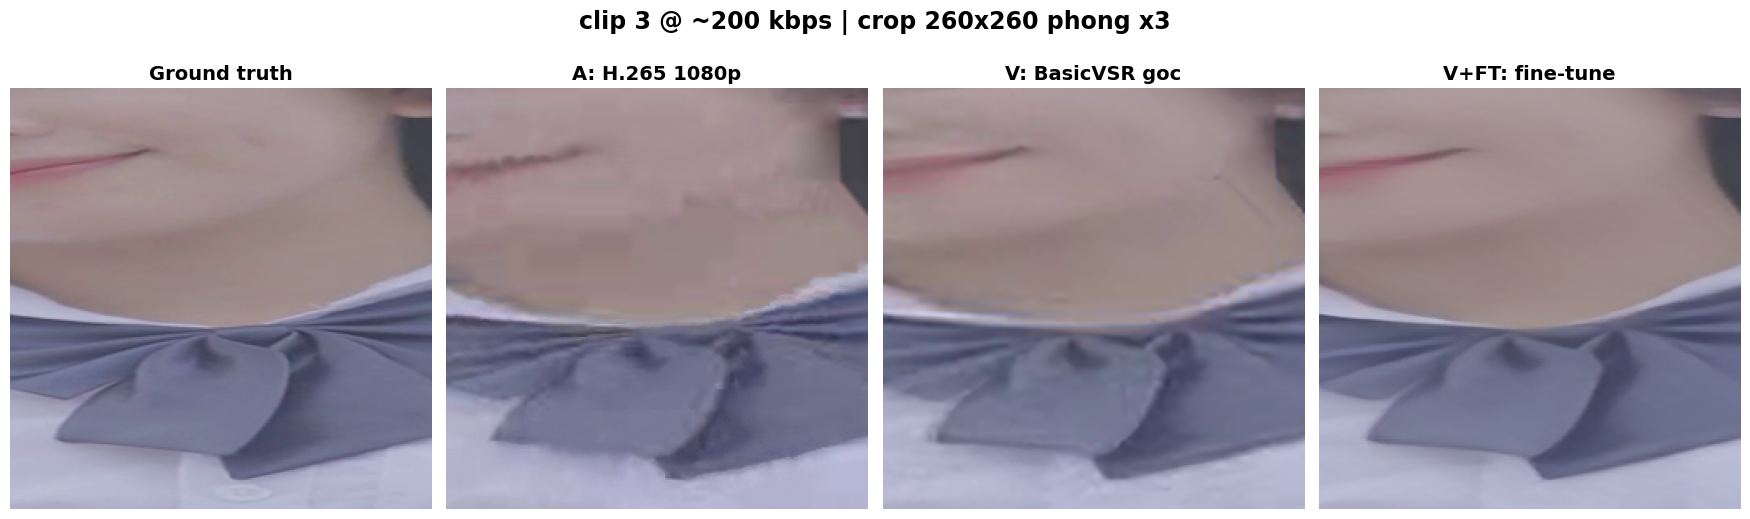

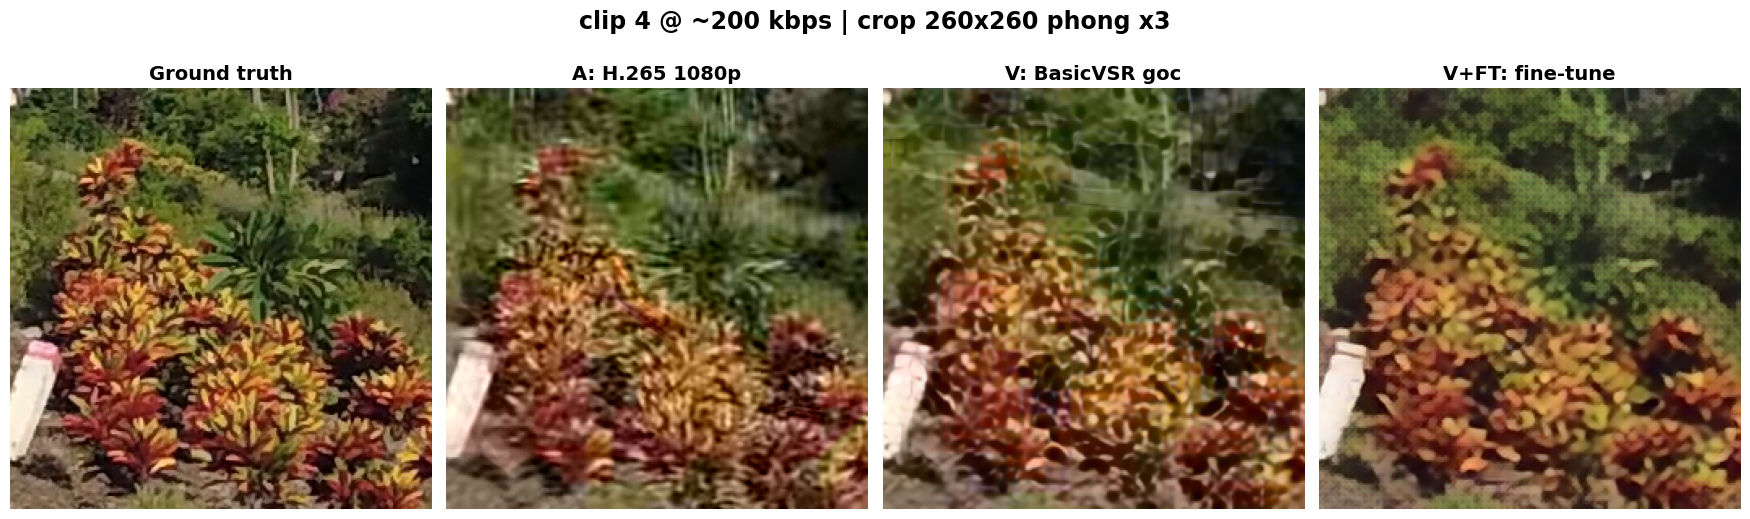


4 video da luu vao Drive/CS232/results/
Xem truc tiep trong notebook:


In [ ]:
# ============================================================
# Xuat video so sanh 4 cot: GT | H.265 1080p | BasicVSR goc | Fine-tune
# Chay sau phan 8. Cac thu muc frame da co san tu buoc danh gia.
# ============================================================

def export_compare(clip_id, br, crop=540, out_name=None):
    cols = [
        ("Ground truth",        DATA/f"gt{clip_id:02d}"),
        ("A: H.265 1080p",      EV/f"A_c{clip_id}_{br}"),
        ("V: BasicVSR goc",     EV/f"V: BasicVSR pretrained_c{clip_id}_{br}"),
        ("V+FT: fine-tune",     EV/f"V+FT: fine-tune H.265_c{clip_id}_{br}"),
    ]
    cols = [(t, Path(d)) for t, d in cols if Path(d).exists()]
    if len(cols) < 2:
        print(f"  bo qua clip{clip_id}@{br}: chi tim thay {len(cols)} thu muc")
        for t, d in [("gt", DATA/f"gt{clip_id:02d}")] + \
                    [(m, EV/f"{m}_c{clip_id}_{br}") for m in
                     ["A", "V: BasicVSR pretrained", "V+FT: fine-tune H.265"]]:
            print(f"    {'OK ' if Path(d).exists() else 'THIEU'} {d}")
        return None

    gts = sorted(cols[0][1].glob("*.png"))
    if not gts: print("  khong co frame GT"); return None

    # chon vung nhieu chi tiet nhat tren frame dau
    g0 = cv2.cvtColor(cv2.imread(str(gts[0])), cv2.COLOR_BGR2GRAY)
    best, pos = -1, (0, 0)
    for y in range(0, max(1, g0.shape[0]-crop), 120):
        for x in range(0, max(1, g0.shape[1]-crop), 120):
            v = cv2.Laplacian(g0[y:y+crop, x:x+crop], cv2.CV_64F).var()
            if v > best: best, pos = v, (y, x)
    y0, x0 = pos

    tmp = EV/f"tmp_cmp_{clip_id}_{br}"
    shutil.rmtree(tmp, ignore_errors=True); tmp.mkdir(parents=True)
    n = 0
    for k in range(len(gts)):
        tiles = []
        for title, d in cols:
            f = d/gts[k].name
            if not f.exists(): break
            im = cv2.imread(str(f))
            if im is None: break
            t = im[y0:y0+crop, x0:x0+crop].copy()
            if t.shape[0] != crop or t.shape[1] != crop:
                t = cv2.resize(t, (crop, crop))
            cv2.rectangle(t, (0,0), (crop,48), (0,0,0), -1)
            cv2.putText(t, title, (10,34), cv2.FONT_HERSHEY_SIMPLEX,
                        0.8, (255,255,255), 2, cv2.LINE_AA)
            tiles.append(t)
        if len(tiles) == len(cols):
            cv2.imwrite(str(tmp/f"{k+1:04d}.png"), np.concatenate(tiles, axis=1)); n += 1

    if n == 0:
        shutil.rmtree(tmp, ignore_errors=True); print("  khong ghep duoc frame nao"); return None

    out = DRIVE/"results"/(out_name or f"compare_c{clip_id}_{br}kbps.mp4")
    run(f'ffmpeg -y -loglevel error -framerate {CFG["fps"]} -i {tmp}/%04d.png '
        f'-c:v libx264 -crf 14 -pix_fmt yuv420p "{out}"', 900)
    shutil.rmtree(tmp, ignore_errors=True)
    print(f"  {out.name}: {n} frame, {len(cols)} cot, {os.path.getsize(out)/1e6:.1f} MB")
    return out


# ---- Anh tinh: crop phong to, co so lieu duoi moi cot ----
def export_still(clip_id, br, crop=260, zoom=3):
    cols = [("Ground truth", DATA/f"gt{clip_id:02d}", None),
            ("A: H.265 1080p", EV/f"A_c{clip_id}_{br}", "A: H.265 1080p"),
            ("V: BasicVSR goc", EV/f"V: BasicVSR pretrained_c{clip_id}_{br}", "V: BasicVSR pretrained"),
            ("V+FT: fine-tune", EV/f"V+FT: fine-tune H.265_c{clip_id}_{br}", "V+FT: fine-tune H.265")]
    cols = [(t,Path(d),m) for t,d,m in cols if Path(d).exists()]
    if len(cols) < 2: return None
    gts = sorted(cols[0][1].glob("*.png")); i = len(gts)//2
    g = cv2.cvtColor(cv2.imread(str(gts[i])), cv2.COLOR_BGR2GRAY)
    best, pos = -1, (0,0)
    for y in range(0, g.shape[0]-crop, crop//2):
        for x in range(0, g.shape[1]-crop, crop//2):
            v = cv2.Laplacian(g[y:y+crop, x:x+crop], cv2.CV_64F).var()
            if v > best: best, pos = v, (y,x)
    y0,x0 = pos
    fig, axes = plt.subplots(1, len(cols), figsize=(4.4*len(cols), 5.6))
    for ax,(title,d,mkey) in zip(np.atleast_1d(axes), cols):
        f = d/gts[i].name
        im = cv2.imread(str(f))
        if im is None: ax.axis("off"); continue
        c = im[y0:y0+crop, x0:x0+crop]
        c = cv2.resize(c, None, fx=zoom, fy=zoom, interpolation=cv2.INTER_NEAREST)
        ax.imshow(c[:,:,::-1]); ax.set_title(title, fontsize=14, fontweight="bold"); ax.axis("off")
        if mkey is not None:
            r = RES[(RES.method==mkey) & (RES.target==br) & (RES.clip==clip_id)]
            if len(r):
                ax.text(.5,-.03, f"LPIPS {r.lpips.iloc[0]:.3f} | PSNR {r.psnr_y.iloc[0]:.1f}",
                        transform=ax.transAxes, ha="center", va="top", fontsize=12)
    fig.suptitle(f"clip {clip_id} @ ~{br} kbps | crop {crop}x{crop} phong x{zoom}",
                 fontsize=17, fontweight="bold")
    plt.tight_layout()
    p = DRIVE/"results"/f"still_c{clip_id}_{br}.png"
    plt.savefig(p, dpi=170, bbox_inches="tight"); plt.show()
    return p


print("Xuat video so sanh:")
made = []
for c in VAL:
    for br in [CFG["eval_bitrates"][0], CFG["eval_bitrates"][-1]]:   # thap nhat va cao nhat
        v = export_compare(c["id"], br)
        if v: made.append(v)

print("\nXuat anh tinh:")
for c in VAL:
    export_still(c["id"], CFG["eval_bitrates"][0])

print(f"\n{len(made)} video da luu vao Drive/CS232/results/")
print("Xem truc tiep trong notebook:")
if made:
    from IPython.display import Video, display as disp
    disp(Video(str(made[0]), embed=True, width=960))

In [ ]:
def export_single(clip_id, br, target=None):
    srcs = {
        "GT":     DATA/f"gt{clip_id:02d}",
        "A_h265": EV/f"A_c{clip_id}_{br}",
        "V_base": EV/f"V: BasicVSR pretrained_c{clip_id}_{br}",
        "V_ft":   EV/f"V+FT: fine-tune H.265_c{clip_id}_{br}",
    }
    # lay kich thuoc GT lam chuan
    gt_dir = Path(srcs["GT"])
    gt_files = sorted(gt_dir.glob("*.png"))
    if not gt_files:
        print(f"  khong co frame GT trong {gt_dir}"); return []
    gh, gw = cv2.imread(str(gt_files[0])).shape[:2]
    if target: gw, gh = target
    print(f"  khung chuan: {gw}x{gh}")

    made = []
    for tag, d in srcs.items():
        d = Path(d)
        if not d.exists():
            print(f"  thieu {d}"); continue
        fs = sorted(d.glob("*.png"))
        if not fs:
            print(f"  rong: {d}"); continue
        h, w = cv2.imread(str(fs[0])).shape[:2]
        out = DRIVE/"results"/f"{tag}_c{clip_id}_{br}kbps.mp4"
        # scale ve dung khung GT; flags=neighbor giu nguyen artifact khi phong to
        flags = "neighbor" if (w < gw or h < gh) else "lanczos"
        vf = f"scale={gw}:{gh}:flags={flags}"
        run(f'ffmpeg -y -loglevel error -framerate {CFG["fps"]} '
            f'-i "{d}/%04d.png" -vf "{vf}" '
            f'-c:v libx264 -crf 14 -pix_fmt yuv420p "{out}"', 900)
        note = f"  (goc {w}x{h})" if (w, h) != (gw, gh) else ""
        print(f"  {out.name}  {os.path.getsize(out)/1e6:.1f} MB{note}")
        made.append(out)
    return made

for br in [200, 1500]:
    print(f"\nclip 2 @ {br} kbps:")
    export_single(2, br)


clip 2 @ 200 kbps:
  khung chuan: 1920x1080
  GT_c2_200kbps.mp4  5.9 MB
  thieu /content/work/vsr_eval/A_c2_200
  thieu /content/work/vsr_eval/V: BasicVSR pretrained_c2_200
  thieu /content/work/vsr_eval/V+FT: fine-tune H.265_c2_200

clip 2 @ 1500 kbps:
  khung chuan: 1920x1080
  GT_c2_1500kbps.mp4  5.9 MB
  thieu /content/work/vsr_eval/A_c2_1500
  thieu /content/work/vsr_eval/V: BasicVSR pretrained_c2_1500
  thieu /content/work/vsr_eval/V+FT: fine-tune H.265_c2_1500
